Training Random Forest...
Training Extra Trees...
Training AdaBoost...
Training Gradient Boosting...
Training Multinomial NB...
Training Logistic Regression...
Training K-Nearest Neighbors...
Training HistGradientBoosting...
Training LightGBM...


c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warn

Training Neural Network...
Training Decision Tree...
Training CatBoost Classifier...
Training BayesianRidge...
Training SVM Linear...
                   Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0         Neural Network     99.90      99.90   99.90     99.90    99.99
1            Extra Trees     99.83      99.83   99.83     99.83   100.00
2          Random Forest     99.69      99.69   99.69     99.69    99.99
3          BayesianRidge     99.69      99.69   99.69     99.69    99.98
4             SVM Linear     99.55      99.55   99.55     99.55    99.94
5    Logistic Regression     99.38      99.38   99.38     99.38    99.94
6         Multinomial NB     99.27      99.27   99.27     99.27    99.95
7               LightGBM     99.03      99.06   99.03     99.04    99.93
8   HistGradientBoosting     98.89      98.93   98.89     98.90    98.84
9          Decision Tree     98.58      98.64   98.58     98.60    98.59
10     Gradient Boosting     97.86      97.89   97.86     97.87

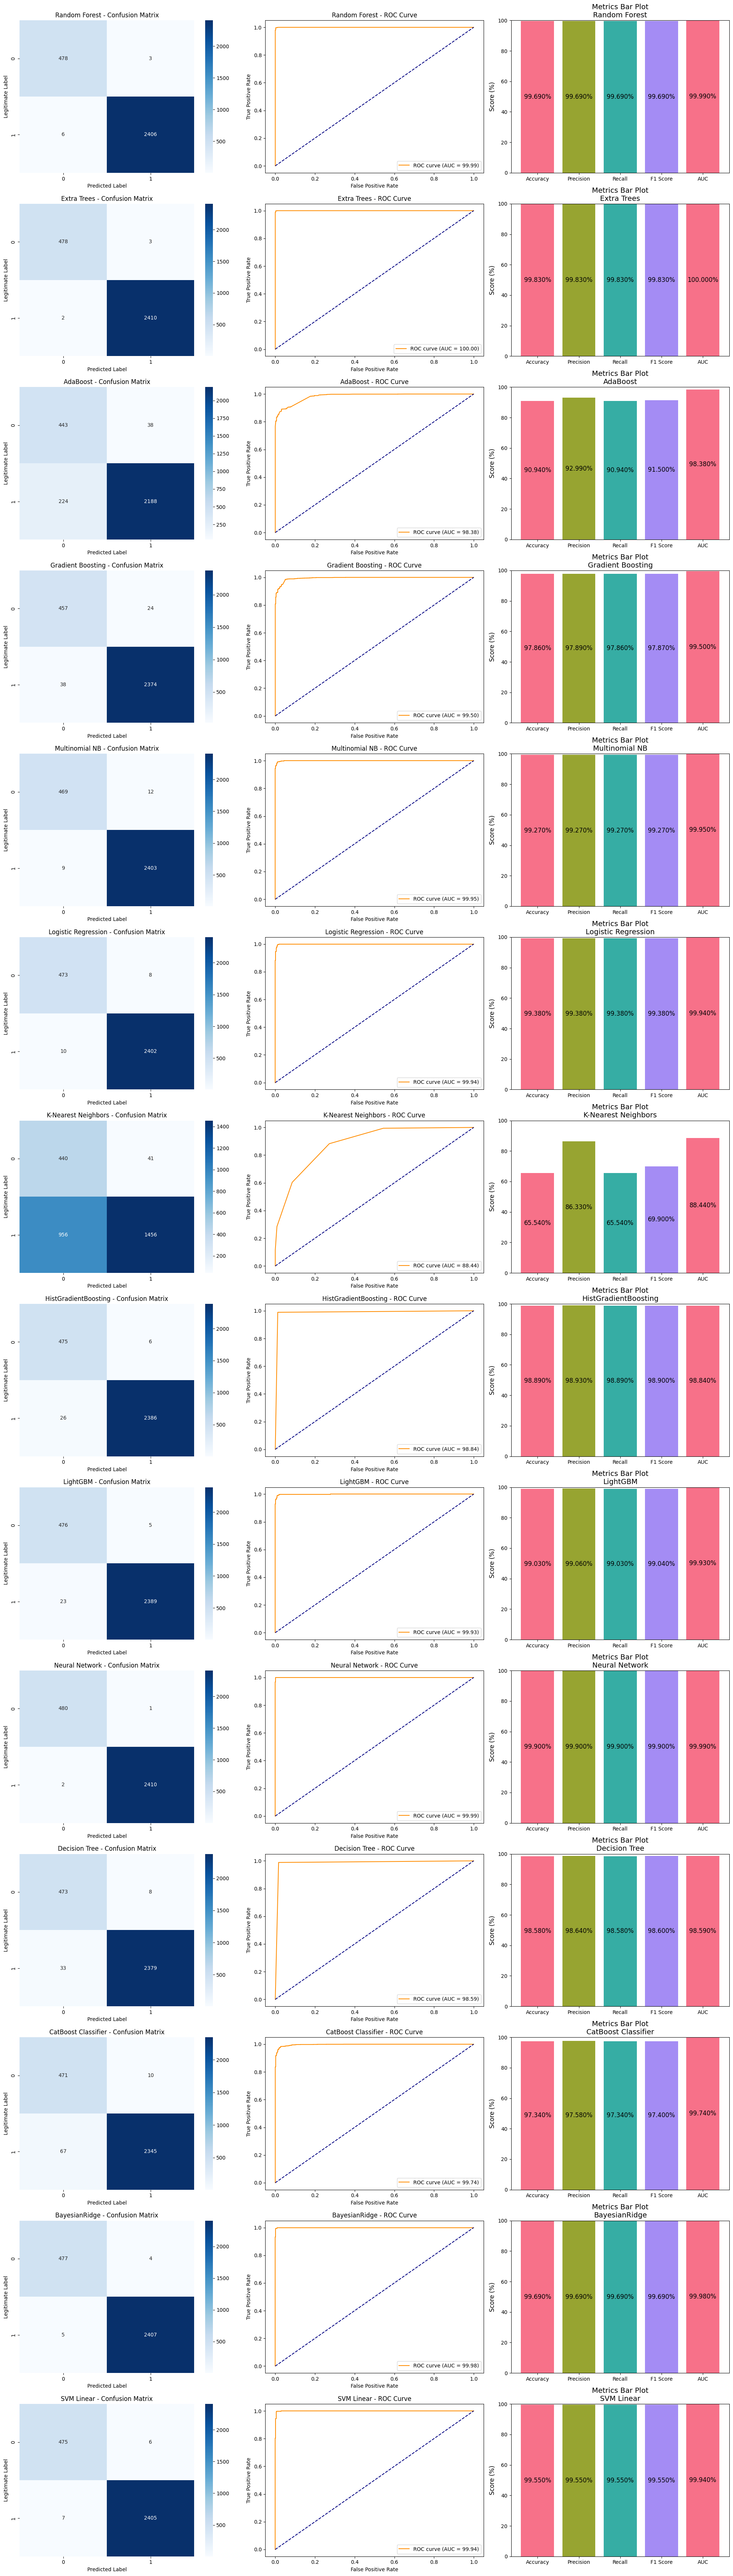

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc)
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, 
                               ExtraTreesClassifier, HistGradientBoostingClassifier)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm.sklearn import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import BayesianRidge
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text) 
    text = text.lower() 
    text = text.split()  
    text = [word for word in text if word not in stop_words] 
    return ' '.join(text)

data = pd.read_csv("C:\\Users\\sobha\\OneDrive\\Desktop\\CODING\\PE1\\updated_file.csv")
df = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")

data = data.dropna(subset=['Email Text'])
df = df.dropna(subset=['Email Text'])

data['Cleaned Email'] = data['Email Text'].apply(clean_text)
df['Cleaned Email'] = df['Email Text'].apply(clean_text)

data1 = pd.concat([data, df], ignore_index=True)

data1['Email Type'] = LabelEncoder().fit_transform(data1['Email Type'])
data['Email Type'] = LabelEncoder().fit_transform(data['Email Type'])
df['Email Type'] = LabelEncoder().fit_transform(df['Email Type'])

X_train, X_test, y_train, y_test = df['Cleaned Email'],data['Cleaned Email'],df['Email Type'],data['Email Type']

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'CatBoost Classifier': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42),
    'BayesianRidge': BayesianRidge(),
    'SVM Linear': SVC(kernel='linear', probability=True, random_state=42)
}

results = []

n_models = len(models)
fig, axes = plt.subplots(n_models, 3, figsize=(20, 5*n_models))
plt.subplots_adjust(hspace=0.4, wspace=0.3)


colors = sns.color_palette('husl', 4)
base_row_idx = 0
for idx, (name, model) in enumerate(models.items()):
        print(f"Training {name}...")
        try:
            if name in ['BayesianRidge', 'HistGradientBoosting']:
                tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
                X_train_tfidf = tfidf.fit_transform(X_train).toarray()
                X_test_tfidf = tfidf.transform(X_test).toarray()
                model.fit(X_train_tfidf, y_train)
                y_pred_continuous = model.predict(X_test_tfidf)
                y_pred = (y_pred_continuous >= 0.5).astype(int)
                y_proba = y_pred_continuous 
            else: 
                tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

                pipeline = Pipeline([
                    ('tfidf', tfidf),
                    ('model', model)
                ])
 
                pipeline.fit(X_train, y_train)

                y_pred = pipeline.predict(X_test)

                try:
                    y_proba = pipeline.predict_proba(X_test)[:, 1]
                except:
                    y_proba = None

            accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
            precision = round(precision_score(y_test, y_pred, average='weighted') * 100, 2)
            recall = round(recall_score(y_test, y_pred, average='weighted') * 100, 2)      
            f1 = round(f1_score(y_test, y_pred, average='weighted') * 100, 2)

            roc_auc = (
                round(auc(*roc_curve(y_test, y_proba)[:2]) * 100, 2)
                if y_proba is not None else 'N/A'
            )

            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'ROC AUC': roc_auc
            })

            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx, 0], cmap='Blues')
            axes[idx, 0].set_title(f'{name} - Confusion Matrix')
            axes[idx, 0].set_xlabel('Predicted Label')
            axes[idx, 0].set_ylabel('Legitimate Label')

            if y_proba is not None:
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                axes[idx, 1].plot(fpr, tpr, color='darkorange', 
                                label=f'ROC curve (AUC = {roc_auc:.2f})')
                axes[idx, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
                axes[idx, 1].set_title(f'{name} - ROC Curve')
                axes[idx, 1].set_xlabel('False Positive Rate')
                axes[idx, 1].set_ylabel('True Positive Rate')
                axes[idx, 1].legend(loc="lower right")
            else:
                axes[idx, 1].text(0.5, 0.5, 'ROC Curve N/A', 
                                horizontalalignment='center', 
                                verticalalignment='center')
                axes[idx, 1].set_title(f'{name} - ROC Curve')

            metrics = [accuracy, precision, recall, f1, roc_auc if roc_auc is not None else 0]
            metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

            bar_plot_row = base_row_idx + idx
            bars = axes[bar_plot_row, 2].bar(metrics_names, metrics, color=colors)
            axes[bar_plot_row, 2].set_title(f'Metrics Bar Plot\n{name}', fontsize=14)
            axes[bar_plot_row, 2].set_ylabel('Score (%)', fontsize=12)
            axes[bar_plot_row, 2].set_ylim(0, 100)

            axes[bar_plot_row, 2].set_xticks(range(len(metrics_names)))
            axes[bar_plot_row, 2].set_xticklabels(metrics_names, ha='center')

            for bar in bars:
                height = bar.get_height()
                axes[bar_plot_row, 2].text(bar.get_x() + bar.get_width() / 2, height * 0.5, 
                                    f'{height:.3f}%', ha='center', va='center', fontsize=12, color='black')
        
        except Exception as e:
            print(f"Error with model {name}: {e}")
            axes[idx, 0].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')
            axes[idx, 1].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')
            bar_plot_row = base_row_idx + idx
            axes[bar_plot_row, 2].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')

results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results.csv", index=False)

print(results_df.sort_values(by='Accuracy', ascending=False, ignore_index=True))

In [3]:
results_df = pd.DataFrame(results)
print(results_df)

                   Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0          Random Forest     99.69      99.69   99.69     99.69    99.99
1            Extra Trees     99.83      99.83   99.83     99.83   100.00
2               AdaBoost     90.94      92.99   90.94     91.50    98.38
3      Gradient Boosting     97.86      97.89   97.86     97.87    99.50
4         Multinomial NB     99.27      99.27   99.27     99.27    99.95
5    Logistic Regression     99.38      99.38   99.38     99.38    99.94
6    K-Nearest Neighbors     65.54      86.33   65.54     69.90    88.44
7   HistGradientBoosting     98.89      98.93   98.89     98.90    98.84
8               LightGBM     99.03      99.06   99.03     99.04    99.93
9         Neural Network     99.90      99.90   99.90     99.90    99.99
10         Decision Tree     98.58      98.64   98.58     98.60    98.59
11   CatBoost Classifier     97.34      97.58   97.34     97.40    99.74
12         BayesianRidge     99.69      99.69   99.

In [4]:
def preprocess_data(X_train, X_test, y_train, y_test):
    # Encode target variable
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
    
    return X_train, X_test, y_train_encoded, y_test_encoded

In [5]:
X_train, X_test, y_train, y_test = preprocess_data(X_train, X_test, y_train, y_test)

Processing First Group of Models...
Training Random Forest...
Training Extra Trees...
Training AdaBoost...
Training Gradient Boosting...
Training Multinomial NB...
Training Logistic Regression...
Training K-Nearest Neighbors...
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
1          Extra Trees     99.83      99.83   99.83     99.83   100.00
0        Random Forest     99.69      99.69   99.69     99.69    99.99
5  Logistic Regression     99.38      99.38   99.38     99.38    99.94
4       Multinomial NB     99.27      99.27   99.27     99.27    99.95
3    Gradient Boosting     97.86      97.89   97.86     97.87    99.50
2             AdaBoost     90.94      92.99   90.94     91.50    98.38
6  K-Nearest Neighbors     65.54      86.33   65.54     69.90    88.44

Processing Second Group of Models...
Training HistGradientBoosting...
Training LightGBM...


c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warn

Training Neural Network...
Training Decision Tree...
Training CatBoost Classifier...
Training BayesianRidge...
Training SVM Linear...
                  Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
2        Neural Network     99.90      99.90   99.90     99.90    99.99
5         BayesianRidge     99.69      99.69   99.69     99.69    99.98
6            SVM Linear     99.55      99.55   99.55     99.55    99.94
1              LightGBM     99.03      99.06   99.03     99.04    99.93
0  HistGradientBoosting     98.89      98.93   98.89     98.90    98.84
3         Decision Tree     98.58      98.64   98.58     98.60    98.59
4   CatBoost Classifier     97.34      97.58   97.34     97.40    99.74

Overall Model Performance (Sorted by Accuracy):
                   Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
9         Neural Network     99.90      99.90   99.90     99.90    99.99
1            Extra Trees     99.83      99.83   99.83     99.83   100.00
0          Random Fore

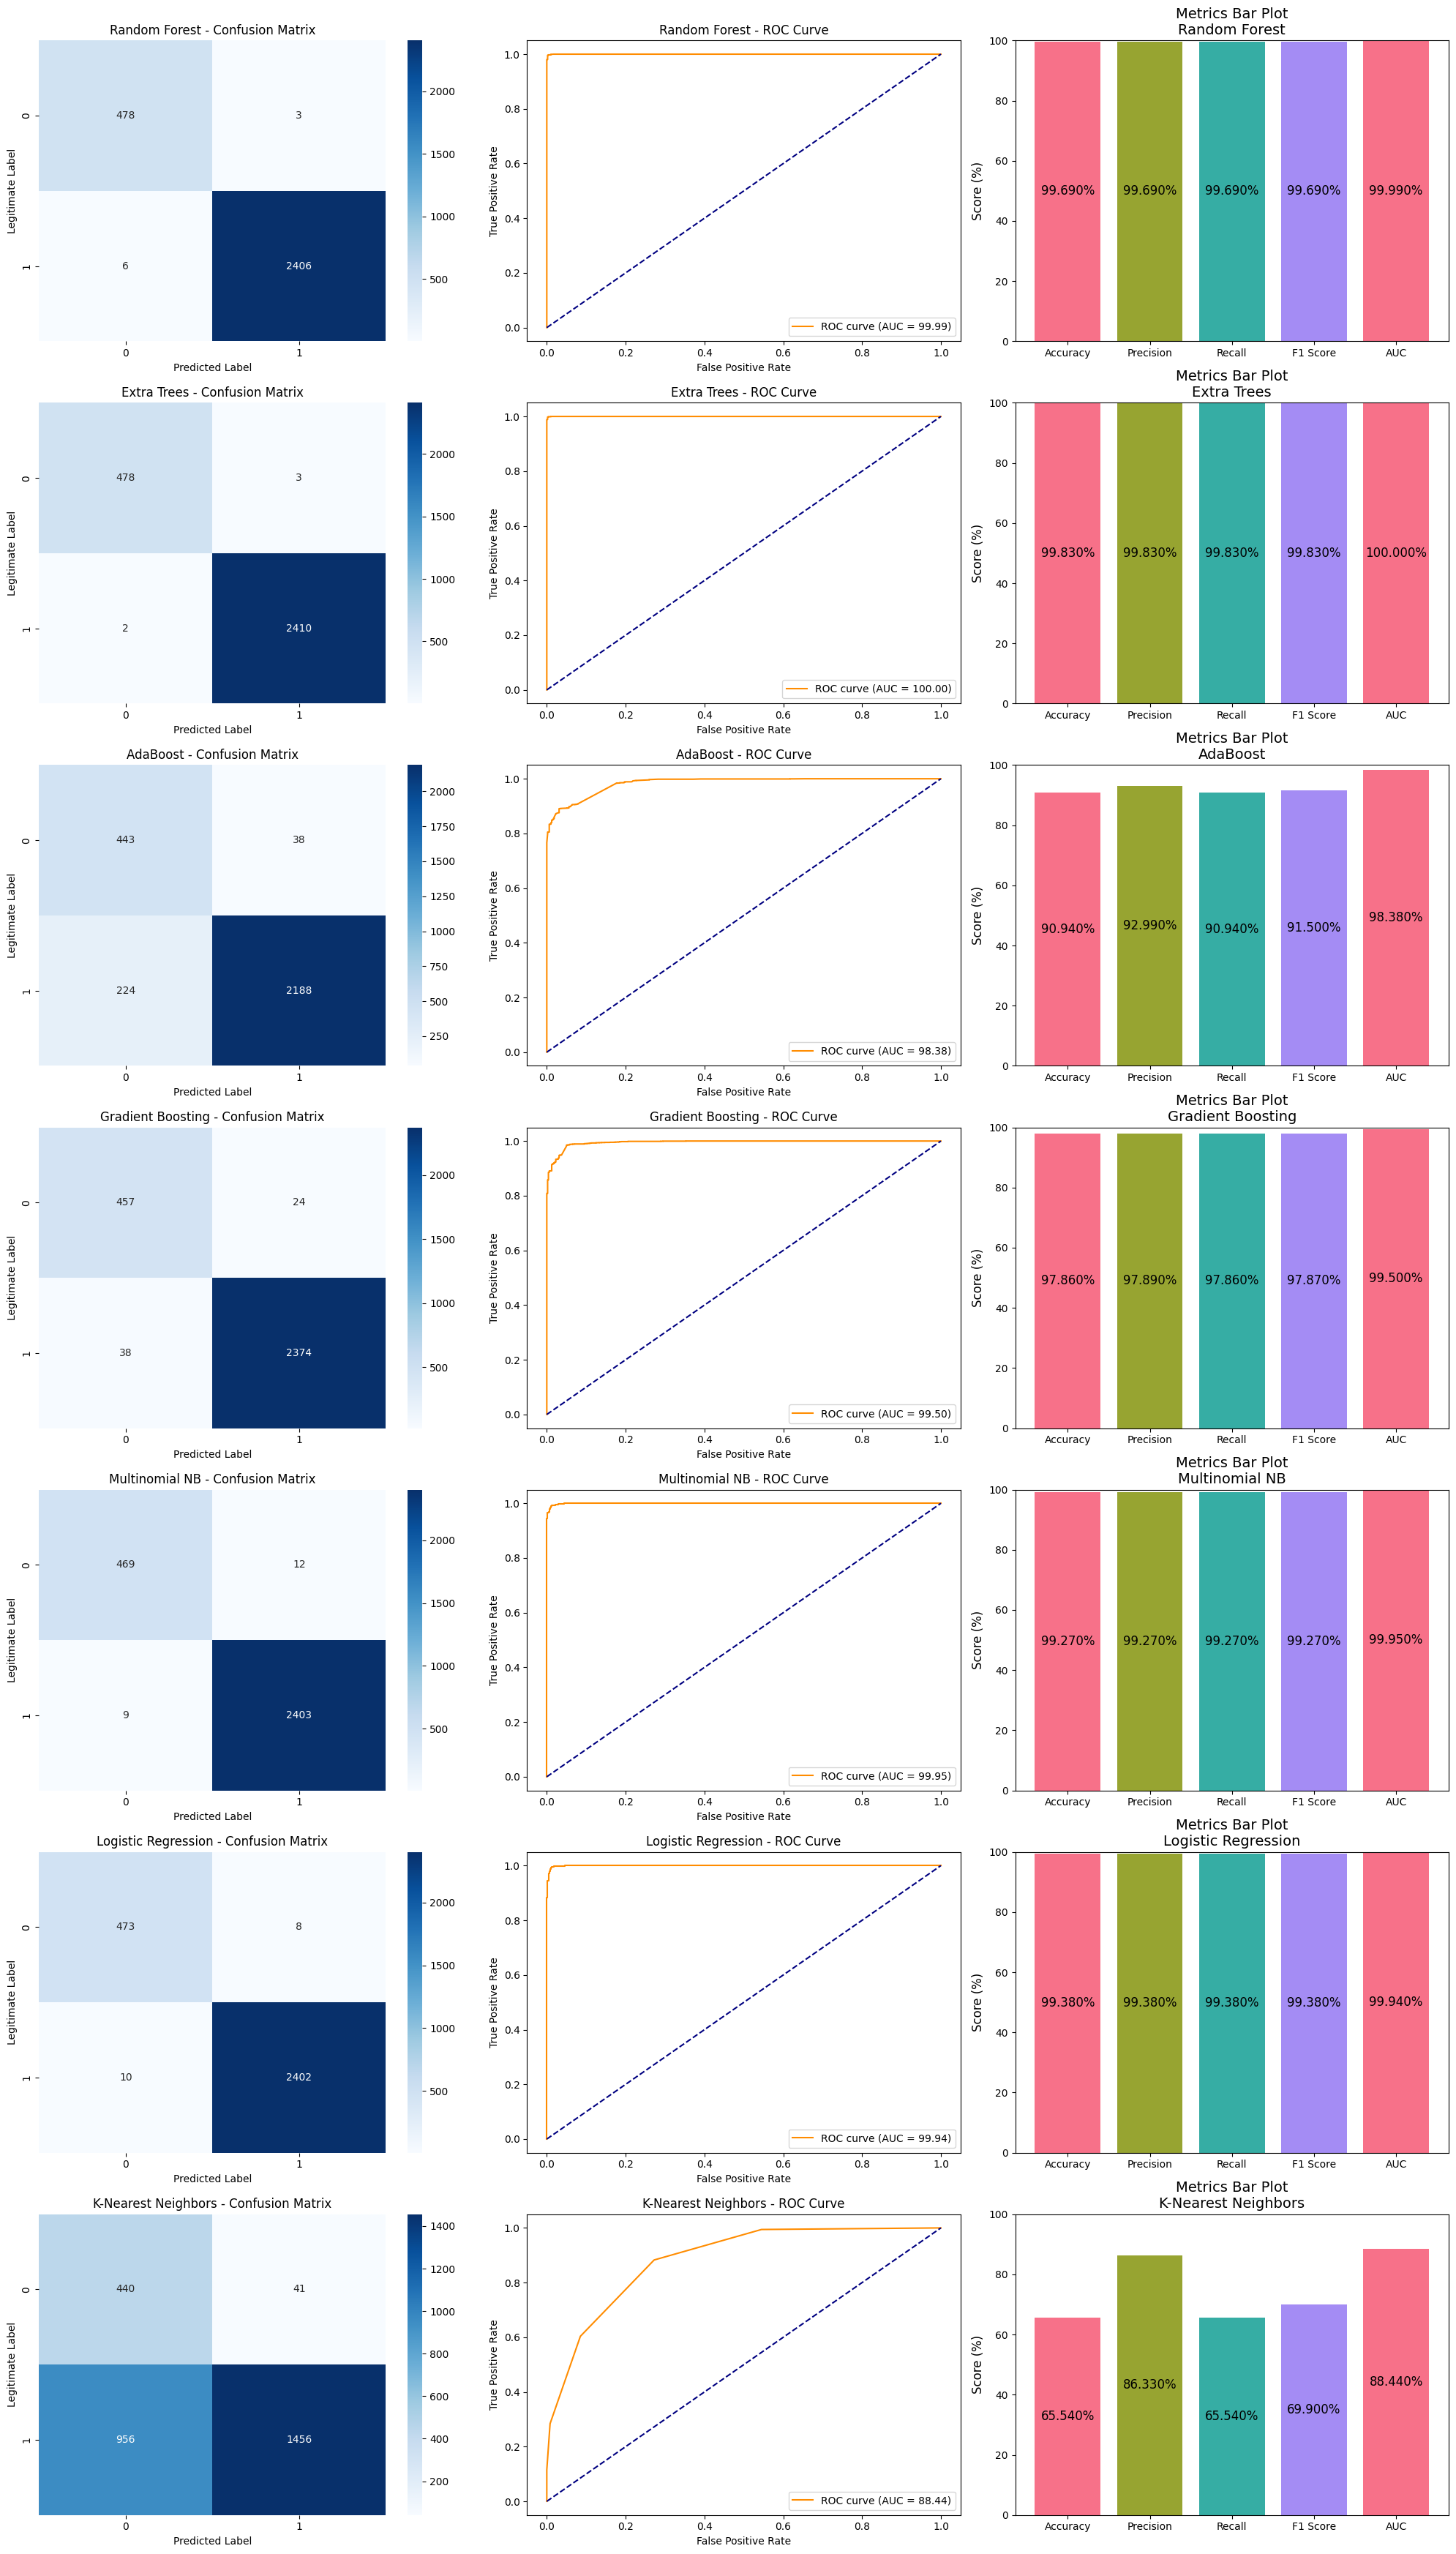

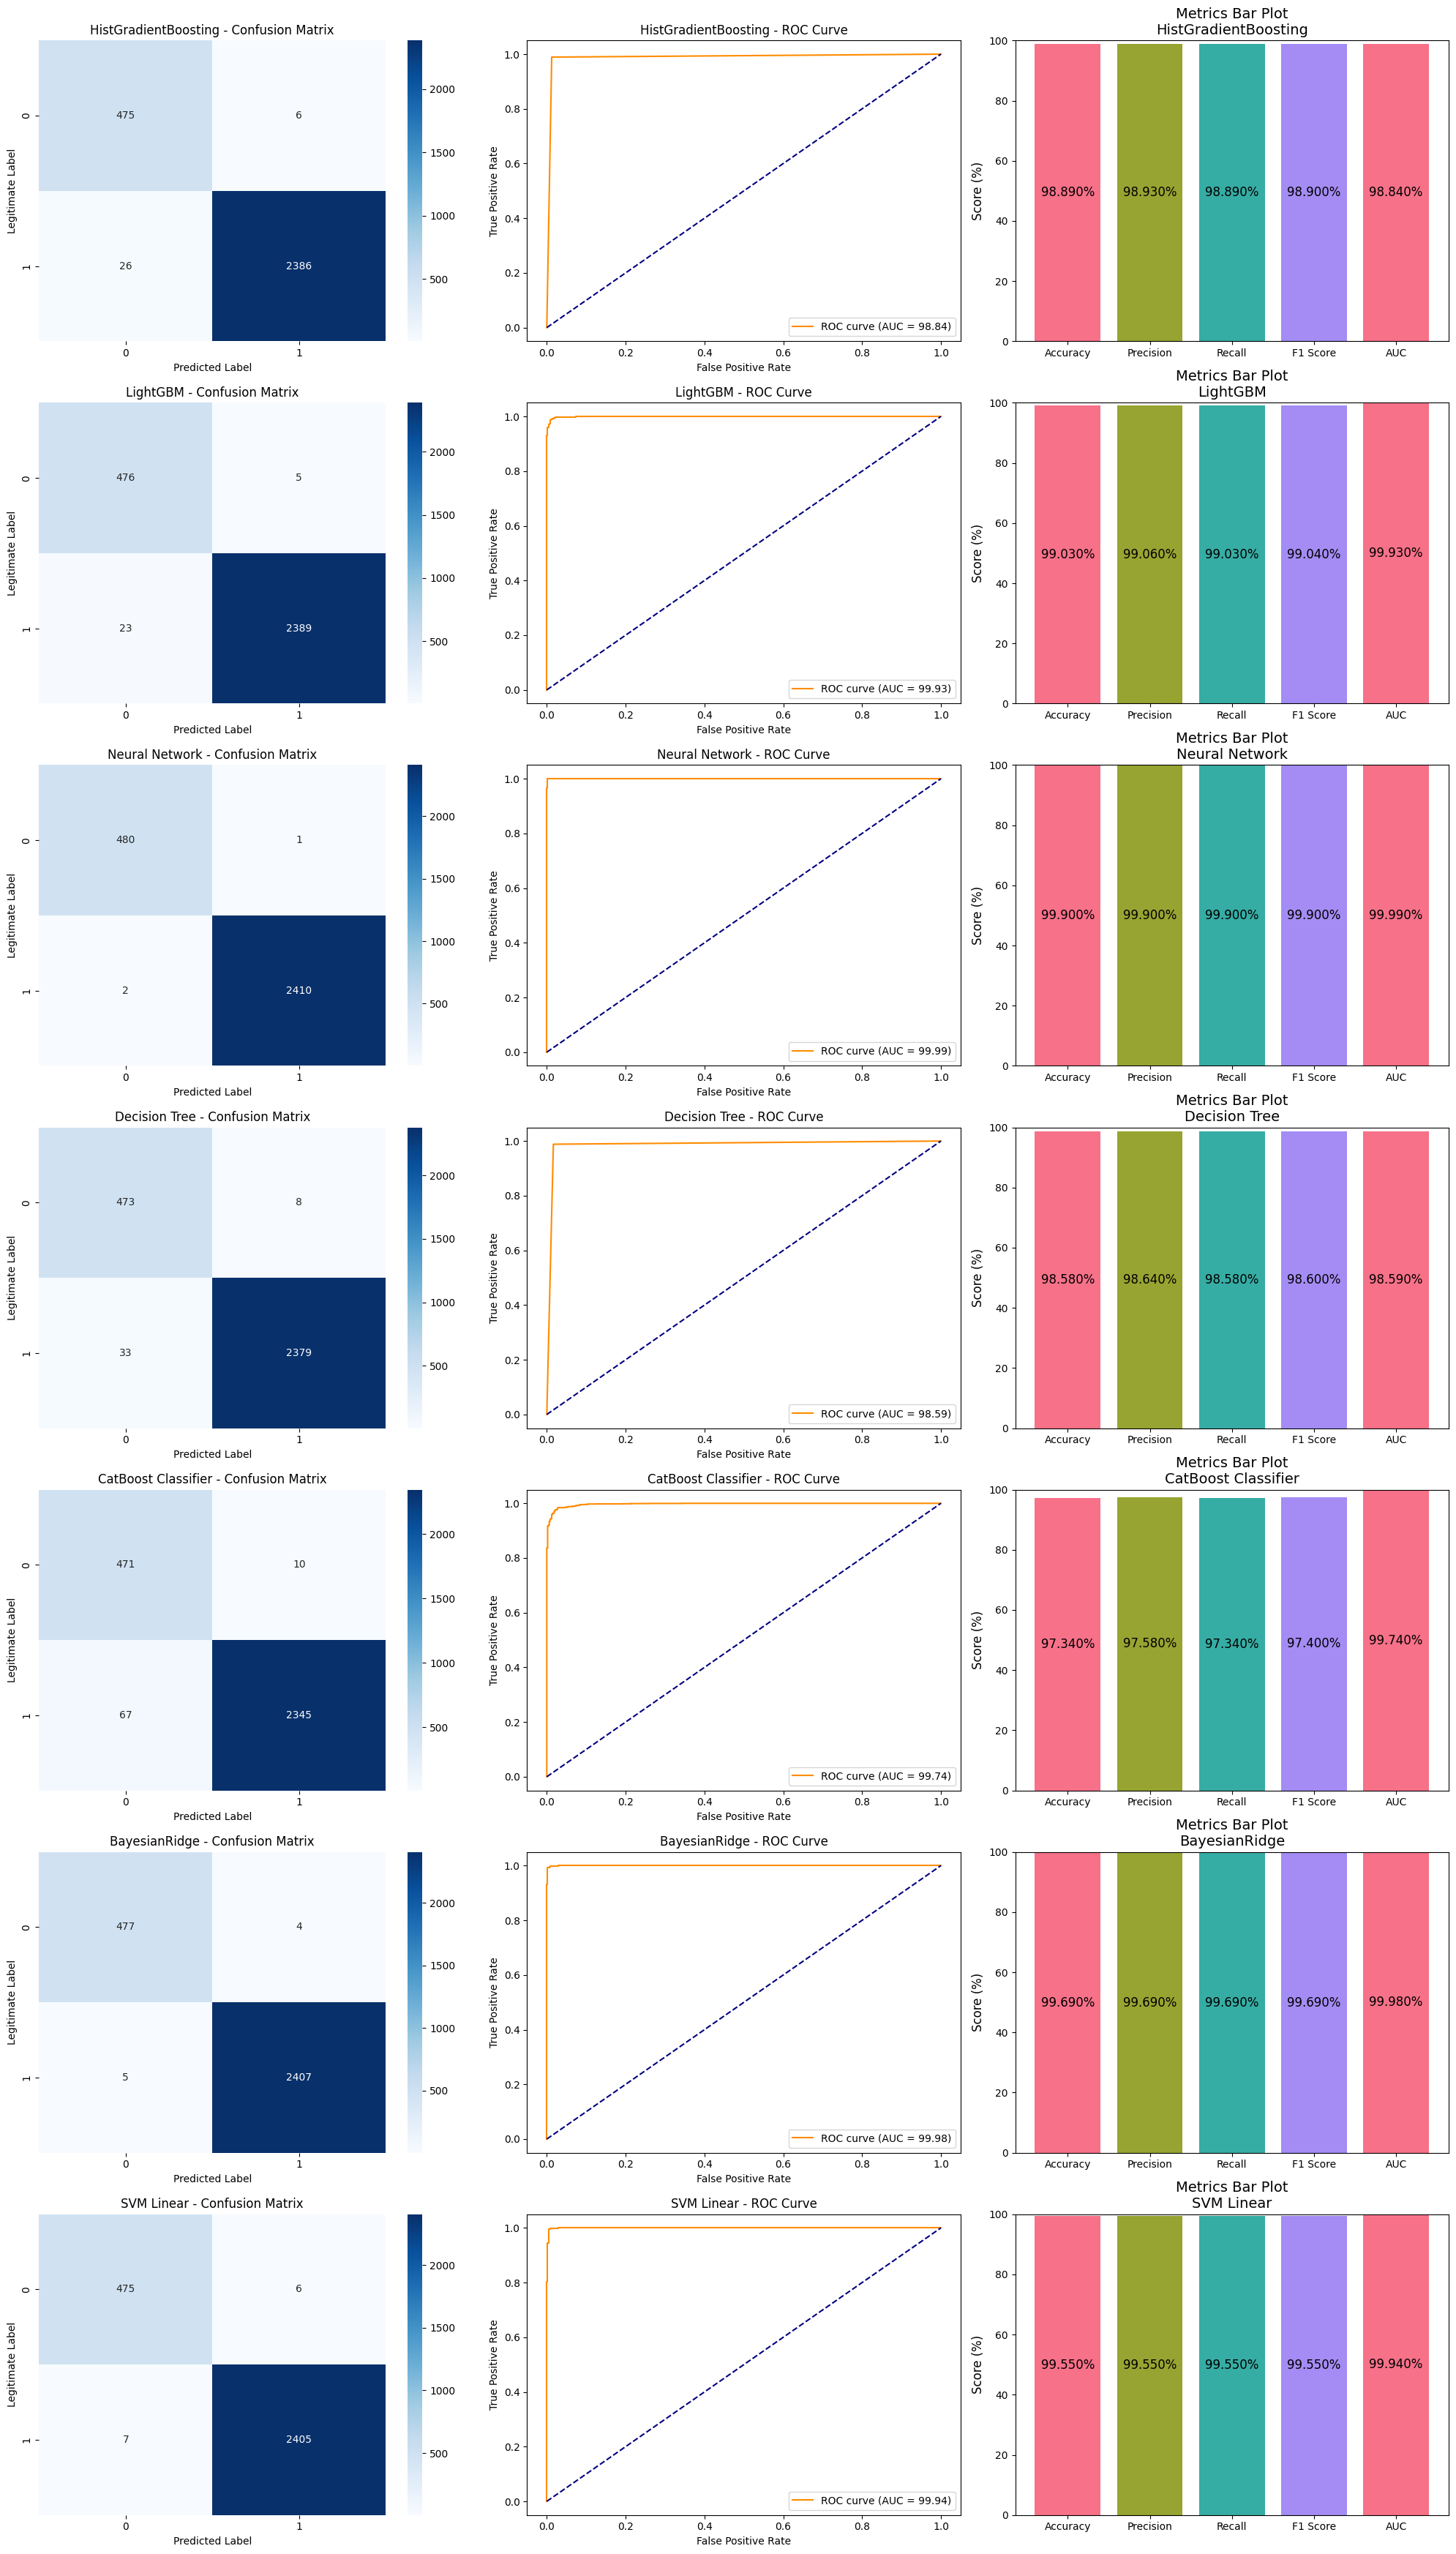

In [6]:
models_group1 = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

models_group2 = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'CatBoost Classifier': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42),
    'BayesianRidge': BayesianRidge(),
    'SVM Linear': SVC(kernel='linear', probability=True, random_state=42)
}

# Function to create plot for a group of models
def create_model_performance_plot(models_group, output_filename):
    # Initialize results storage
    results = []

    # Visualization preparation
    n_models = len(models_group)
    fig, axes = plt.subplots(n_models, 3, figsize=(20, 5*n_models))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # Color palette
    colors = sns.color_palette('husl', 4)

    # Evaluate each model
    for idx, (name, model) in enumerate(models_group.items()):
        print(f"Training {name}...")
        try:
            if name in ['BayesianRidge', 'HistGradientBoosting']:
                # Handle non-standard models separately
                tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
                X_train_tfidf = tfidf.fit_transform(X_train).toarray()
                X_test_tfidf = tfidf.transform(X_test).toarray()
                model.fit(X_train_tfidf, y_train)
                y_pred_continuous = model.predict(X_test_tfidf)
                y_pred = (y_pred_continuous >= 0.5).astype(int)
                y_proba = y_pred_continuous  # Use continuous predictions for ROC curve
            # Prepare TF-IDF vectorization
            else:
                tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
                
                # Create pipeline
                pipeline = Pipeline([
                    ('tfidf', tfidf),
                    ('model', model)
                ])
                
                # Fit pipeline
                pipeline.fit(X_train, y_train)
                
                # Predictions
                y_pred = pipeline.predict(X_test)
                
                # Probability predictions (if available)
                try:
                    y_proba = pipeline.predict_proba(X_test)[:, 1]
                except:
                    y_proba = None
            # Compute metrics
            accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
            precision = round(precision_score(y_test, y_pred, average='weighted') * 100, 2)
            recall = round(recall_score(y_test, y_pred, average='weighted') * 100, 2)      
            f1 = round(f1_score(y_test, y_pred, average='weighted') * 100, 2)

            # ROC AUC (if probabilities available)
            roc_auc = (
                round(auc(*roc_curve(y_test, y_proba)[:2]) * 100, 2)
                if y_proba is not None else 'N/A'
            )
            
            # Store results
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'ROC AUC': roc_auc
            })
            
            # Confusion Matrix
            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx, 0], cmap='Blues')
            axes[idx, 0].set_title(f'{name} - Confusion Matrix')
            axes[idx, 0].set_xlabel('Predicted Label')
            axes[idx, 0].set_ylabel('Legitimate Label')
            
            # ROC Curve
            if y_proba is not None:
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                axes[idx, 1].plot(fpr, tpr, color='darkorange', 
                                label=f'ROC curve (AUC = {roc_auc:.2f})')
                axes[idx, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
                axes[idx, 1].set_title(f'{name} - ROC Curve')
                axes[idx, 1].set_xlabel('False Positive Rate')
                axes[idx, 1].set_ylabel('True Positive Rate')
                axes[idx, 1].legend(loc="lower right")
            else:
                axes[idx, 1].text(0.5, 0.5, 'ROC Curve N/A', 
                                horizontalalignment='center', 
                                verticalalignment='center')
                axes[idx, 1].set_title(f'{name} - ROC Curve')
            
            # Performance Metrics Bar Plot
            metrics = [accuracy, precision, recall, f1, roc_auc if roc_auc is not None else 0]
            metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
            
            bars = axes[idx, 2].bar(metrics_names, metrics, color=colors)
            axes[idx, 2].set_title(f'Metrics Bar Plot\n{name}', fontsize=14)
            axes[idx, 2].set_ylabel('Score (%)', fontsize=12)
            axes[idx, 2].set_ylim(0, 100)

            axes[idx, 2].set_xticks(range(len(metrics_names)))
            axes[idx, 2].set_xticklabels(metrics_names, ha='center')

            for bar in bars:
                height = bar.get_height()
                axes[idx, 2].text(bar.get_x() + bar.get_width() / 2, height * 0.5, 
                                    f'{height:.3f}%', ha='center', va='center', fontsize=12, color='black')
        
        except Exception as e:
            print(f"Error with model {name}: {e}")
            # If error occurs, fill the subplots with error message
            axes[idx, 0].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')
            axes[idx, 1].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')
            axes[idx, 2].text(0.5, 0.5, f'Error: {str(e)}', 
                            horizontalalignment='center', 
                            verticalalignment='center')

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    # Save results to CSV
    results_df = pd.DataFrame(results)
    #results_df.to_csv(output_filename.replace('.png', '_results.csv'), index=False)

    # Display results
    print(results_df.sort_values(by='Accuracy', ascending=False))
    
    return results_df

# Create plots for both model groups
print("Processing First Group of Models...")
results_group1 = create_model_performance_plot(models_group1, 'model_performance_comparison_group1.png')

print("\nProcessing Second Group of Models...")
results_group2 = create_model_performance_plot(models_group2, 'model_performance_comparison_group2.png')

# Combine and sort all results
all_results = pd.concat([results_group1, results_group2], ignore_index=True)
print("\nOverall Model Performance (Sorted by Accuracy):")
print(all_results.sort_values(by='Accuracy', ascending=False))

In [7]:
all_results.sort_values(by='Accuracy', ascending=False, ignore_index=True).set_index('Model')

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Neural Network,99.90,99.90,99.90,99.90,99.99
Extra Trees,99.83,99.83,99.83,99.83,100.00
Random Forest,99.69,99.69,99.69,99.69,99.99
BayesianRidge,99.69,99.69,99.69,99.69,99.98
SVM Linear,99.55,99.55,99.55,99.55,99.94
Logistic Regression,99.38,99.38,99.38,99.38,99.94
Multinomial NB,99.27,99.27,99.27,99.27,99.95
LightGBM,99.03,99.06,99.03,99.04,99.93
HistGradientBoosting,98.89,98.93,98.89,98.90,98.84


In [8]:
from tabulate import tabulate
print(tabulate(all_results.sort_values(by='Accuracy', ascending=False, ignore_index=True).set_index('Model'), headers='keys', tablefmt='pretty'))

+----------------------+----------+-----------+--------+----------+---------+
|        Model         | Accuracy | Precision | Recall | F1 Score | ROC AUC |
+----------------------+----------+-----------+--------+----------+---------+
|    Neural Network    |   99.9   |   99.9    |  99.9  |   99.9   |  99.99  |
|     Extra Trees      |  99.83   |   99.83   | 99.83  |  99.83   |  100.0  |
|    Random Forest     |  99.69   |   99.69   | 99.69  |  99.69   |  99.99  |
|    BayesianRidge     |  99.69   |   99.69   | 99.69  |  99.69   |  99.98  |
|      SVM Linear      |  99.55   |   99.55   | 99.55  |  99.55   |  99.94  |
| Logistic Regression  |  99.38   |   99.38   | 99.38  |  99.38   |  99.94  |
|    Multinomial NB    |  99.27   |   99.27   | 99.27  |  99.27   |  99.95  |
|       LightGBM       |  99.03   |   99.06   | 99.03  |  99.04   |  99.93  |
| HistGradientBoosting |  98.89   |   98.93   | 98.89  |   98.9   |  98.84  |
|    Decision Tree     |  98.58   |   98.64   | 98.58  |   98.6 